# 港口集卡智能调度系统

基于图搜索、智能优化与强化学习的港口集卡协同调度研究

- 第一层: 传统图算法 — Greedy + Dijkstra
- 第二层: 智能优化 — GA + A*
- 第三层: 港口场景增强 — CA-GA + A* (拥堵感知)
- 第四层: 智能决策 — NSGA-II + A* (多目标)

In [16]:
%matplotlib inline
import sys, os, time
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from data import get_graph, get_coords, get_trucks, get_tasks, get_dynamic_tasks
from pathfinding import astar, dijkstra
from assignment import run_ga, run_greedy, run_ca_ga
from nsga2_optimizer import run_nsga2
from rl_agent import run_q_learning
from dqn_agent import run_dqn
from output import (compute_metrics,
                    save_heatmap, save_pareto_front, save_rl_curve,
                    save_comparison_chart, save_charts, save_results, print_summary)

print('所有模块导入成功')

所有模块导入成功


In [17]:
# \u52a0\u8f7d\u6570\u636e
graph = get_graph()
coords = get_coords()
trucks = get_trucks()
tasks = get_tasks()
dynamic_tasks = get_dynamic_tasks()

print(f'\u8def\u7f51: {len(graph)} \u8282\u70b9')
print(f'\u5361\u8f66: {len(trucks)} \u8f86, \u8d77\u59cb\u4f4d\u7f6e: {[t[1] for t in trucks]}')
print(f'\u9759\u6001\u4efb\u52a1: {len(tasks)} \u4e2a')
print(f'\u52a8\u6001\u4efb\u52a1: {len(dynamic_tasks)} \u4e2a (\u5206\u6279\u5230\u8fbe)')

路网: 40 节点
卡车: 12 辆, 起始位置: [1, 5, 9, 13, 17, 21, 25, 29, 33, 37, 3, 39]
静态任务: 80 个
动态任务: 80 个 (分批到达)


In [18]:
# \u9884\u5904\u7406\uff1a\u52a9\u624b\u51fd\u6570
def _build_dist_cache(graph, coords, path_fn):
    node_ids = list(graph.keys())
    cache = {}
    for s in node_ids:
        for e in node_ids:
            if s != e and (s, e) not in cache:
                _, d = path_fn(graph, coords, s, e)
                cache[(s, e)] = d
                cache[(e, s)] = d
        cache[(s, s)] = 0.0
    return cache

def _compute_edge_usage(paths):
    usage = defaultdict(int)
    for tid, path in paths.items():
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            usage[(min(u, v), max(u, v))] += 1
    return dict(usage)

def _build_paths(assignment, trucks, tasks, graph, coords, path_fn):
    task_dict = {t[0]: (t[1], t[2]) for t in tasks}
    truck_start = {t[0]: t[1] for t in trucks}
    paths = {}
    for tid, task_ids in assignment.items():
        pos = truck_start[tid]
        full = [pos]
        for jid in task_ids:
            js, je = task_dict[jid]
            seg1, _ = path_fn(graph, coords, pos, js)
            seg2, _ = path_fn(graph, coords, js, je)
            full += seg1[1:] + seg2[1:]
            pos = je
        paths[tid] = full
    return paths

def _build_paths_2arg(assignment, trucks, tasks, graph, path_fn):
    task_dict = {t[0]: (t[1], t[2]) for t in tasks}
    truck_start = {t[0]: t[1] for t in trucks}
    paths = {}
    for tid, task_ids in assignment.items():
        pos = truck_start[tid]
        full = [pos]
        for jid in task_ids:
            js, je = task_dict[jid]
            seg1, _ = path_fn(graph, pos, js)
            seg2, _ = path_fn(graph, js, je)
            full += seg1[1:] + seg2[1:]
            pos = je
        paths[tid] = full
    return paths

dist_cache = _build_dist_cache(graph, coords, astar)
print(f'\u8ddd\u79bb\u7f13\u5b58\u5df2\u6784\u5efa ({len(dist_cache)} \u6761)')

距离缓存已构建 (1600 条)


---
## Greedy + Dijkstra (Baseline)

In [19]:
print('\u8fd0\u884c \u8d2a\u5fc3+Dijkstra...')
gr_assign, gr_rt = run_greedy(graph, trucks, tasks, dijkstra)
gr_paths = _build_paths_2arg(gr_assign, trucks, tasks, graph, dijkstra)
gr_eu = _compute_edge_usage(gr_paths)
gr_result = compute_metrics(gr_assign, gr_paths, trucks, tasks,
                            edge_usage=gr_eu, dist_cache=dist_cache)
gr_result['runtime'] = gr_rt
gr_result['convergence'] = []
print(f'  \u603b\u8ddd\u79bb: {gr_result["total_dist"]:.2f} km')
print(f'  \u5b8c\u5de5\u65f6\u95f4: {gr_result["makespan"]:.4f} h')
print(f'  \u7a7a\u9a76\u7387: {gr_result["empty_ratio"]:.3f}')
print(f'  \u62e5\u5835\u6307\u6570: {gr_result["congestion"]:.2f}')

运行 贪心+Dijkstra...
  总距离: 2383.00 km
  完工时间: 22.7000 h
  空驶率: 0.448
  拥堵指数: 1777.83


---
## GA + A*

运行 GA+A*...
  总距离: 2289.00 km
  完工时间: 23.4000 h
  空驶率: 0.426
  拥堵指数: 1430.56
  运行时间: 8.7374 s


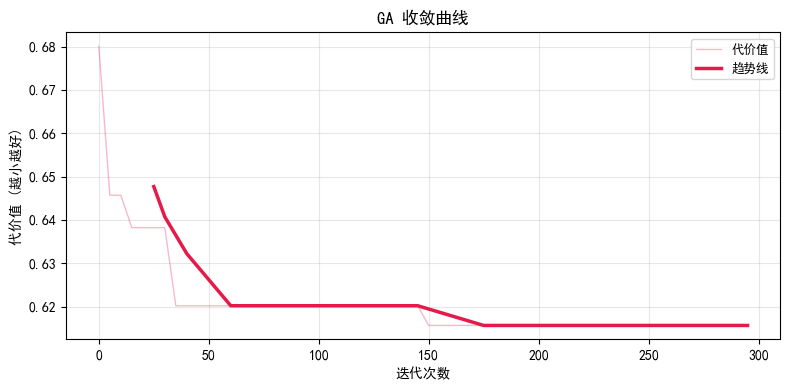

In [20]:
print('运行 GA+A*...')
ga_assign, ga_rt, ga_conv = run_ga(graph, coords, trucks, tasks, astar)
ga_paths = _build_paths(ga_assign, trucks, tasks, graph, coords, astar)
ga_eu = _compute_edge_usage(ga_paths)
ga_result = compute_metrics(ga_assign, ga_paths, trucks, tasks,
                            edge_usage=ga_eu, dist_cache=dist_cache)
ga_result['runtime'] = ga_rt
ga_result['convergence'] = ga_conv
ga_result['assignment'] = ga_assign
ga_result['edge_usage'] = ga_eu
print(f'  总距离: {ga_result["total_dist"]:.2f} km')
print(f'  完工时间: {ga_result["makespan"]:.4f} h')
print(f'  空驶率: {ga_result["empty_ratio"]:.3f}')
print(f'  拥堵指数: {ga_result["congestion"]:.2f}')
print(f'  运行时间: {ga_result["runtime"]:.4f} s')

# 画收敛曲线（稀疏采样 + 滑动平均平滑）
step = max(1, len(ga_conv) // 60)
sampled = ga_conv[::step]
x_sampled = range(0, len(ga_conv), step)[:len(sampled)]

fig, ax = plt.subplots(figsize=(8, 4))
# 原始采样点（半透明）
ax.plot(x_sampled, sampled, color='#e6194b', lw=1, alpha=0.3, label='代价值')
# 滑动平均（加粗清晰）
window_smooth = max(1, len(sampled) // 10)
if len(sampled) >= window_smooth:
    smooth = np.convolve(sampled, np.ones(window_smooth)/window_smooth, mode='valid')
    ax.plot(x_sampled[window_smooth-1:], smooth, color='#e6194b', lw=2.5, label='趋势线')
ax.set_xlabel('迭代次数')
ax.set_ylabel('代价值 (越小越好)')
ax.set_title('GA 收敛曲线')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## CA-GA + A*

In [21]:
print('\u8fd0\u884c CA-GA+A* (\u62e5\u5835\u611f\u77e5)...')
ca_assign, ca_rt, ca_conv = run_ca_ga(graph, coords, trucks, tasks, astar)
ca_paths = _build_paths(ca_assign, trucks, tasks, graph, coords, astar)
ca_eu = _compute_edge_usage(ca_paths)
ca_result = compute_metrics(ca_assign, ca_paths, trucks, tasks,
                            edge_usage=ca_eu, dist_cache=dist_cache)
ca_result['runtime'] = ca_rt
ca_result['convergence'] = ca_conv
ca_result['assignment'] = ca_assign
ca_result['edge_usage'] = ca_eu
print(f'  \u603b\u8ddd\u79bb: {ca_result["total_dist"]:.2f} km')
print(f'  \u5b8c\u5de5\u65f6\u95f4: {ca_result["makespan"]:.4f} h')
print(f'  \u7a7a\u9a76\u7387: {ca_result["empty_ratio"]:.3f}')
print(f'  \u62e5\u5835\u6307\u6570: {ca_result["congestion"]:.2f}')

运行 CA-GA+A* (拥堵感知)...
  总距离: 2224.00 km
  完工时间: 23.3000 h
  空驶率: 0.409
  拥堵指数: 1115.16


---
## NSGA-II + A*

In [22]:
print('运行 NSGA-II+A* (多目标优化)...')
nsga2_assign, nsga2_rt, pareto_front, hv_history = run_nsga2(
    graph, coords, trucks, tasks, astar,
    pop_size=200, n_gen=200,
    select_by='knee', verbose=True
)
nsga2_paths = _build_paths(nsga2_assign, trucks, tasks, graph, coords, astar)
nsga2_eu = _compute_edge_usage(nsga2_paths)
nsga2_result = compute_metrics(nsga2_assign, nsga2_paths, trucks, tasks,
                               edge_usage=nsga2_eu, dist_cache=dist_cache)
nsga2_result['runtime'] = nsga2_rt
nsga2_result['assignment'] = nsga2_assign
nsga2_result['edge_usage'] = nsga2_eu
nsga2_result['pareto_front'] = pareto_front
nsga2_result['hv_history'] = hv_history
print(f'  总距离: {nsga2_result["total_dist"]:.2f} km')
print(f'  完工时间: {nsga2_result["makespan"]:.4f} h')
print(f'  空驶率: {nsga2_result["empty_ratio"]:.3f}')
print(f'  拥堵指数: {nsga2_result["congestion"]:.2f}')
print(f'  运行时间: {nsga2_result["runtime"]:.4f} s')
print(f'  Pareto前沿点数: {len(pareto_front)}')

运行 NSGA-II+A* (多目标优化)...
预计算距离缓存 (40 节点)...
初始化 NSGA-II (pop=200, gen=200, obj=2)...
运行多目标优化 (启用 HV 跟踪)...
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |      5 |             - |             -
     2 |      400 |      7 |  0.0604026846 |         ideal
     3 |      600 |     10 |  0.1711229947 |         ideal
     4 |      800 |     12 |  0.0922330097 |         ideal
     5 |     1000 |      6 |  0.1604938272 |         ideal
     6 |     1200 |      6 |  0.0697316947 |             f
     7 |     1400 |      7 |  0.0576271186 |         ideal
     8 |     1600 |      7 |  0.0062893082 |         ideal
     9 |     1800 |      7 |  0.2164179104 |         ideal
    10 |     2000 |      7 |  0.1352177184 |             f
    11 |     2200 |      7 |  0.0945945946 |         ideal
    12 |     2400 |      8 |  0.1492537313 |         ideal
    13 |     2600 |      6 |  0.0208333333 |         ideal
    14 |     2800 |      5 |  0.1111111111 |         ideal
    15 |

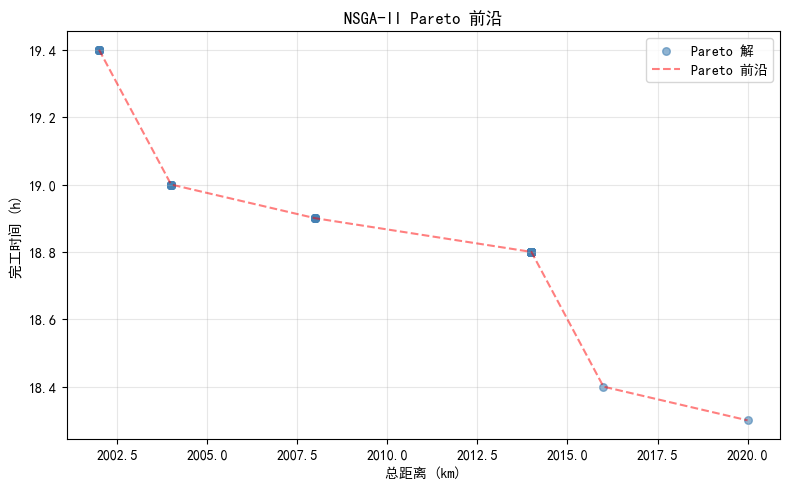

Pareto 前沿包含 200 个非支配解
  距离范围: 2002 ~ 2020 km
  完工时间范围: 18.3 ~ 19.4 h


In [23]:
# 显示 Pareto 前沿（修复去重+线性连接 bug）
if pareto_front:
    dists = [p['total_dist'] for p in pareto_front]
    makespans = [p['makespan'] for p in pareto_front]

    fig, ax = plt.subplots(figsize=(8, 5))
    # 散点：所有 Pareto 解
    ax.scatter(dists, makespans, c='steelblue', s=30, alpha=0.6, label='Pareto 解')

    # 线：真实 Pareto 前沿（按非支配排序）
    pareto = sorted(zip(dists, makespans), key=lambda x: (x[0], x[1]))
    pf_dists, pf_ms = [], []
    best_ms = float('inf')
    for d, m in pareto:
        if m < best_ms:
            pf_dists.append(d)
            pf_ms.append(m)
            best_ms = m
    ax.plot(pf_dists, pf_ms, 'r--', alpha=0.5, lw=1.5, label='Pareto 前沿')

    ax.set_xlabel('总距离 (km)')
    ax.set_ylabel('完工时间 (h)')
    ax.set_title('NSGA-II Pareto 前沿')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Pareto 前沿包含 {len(pareto_front)} 个非支配解')
    print(f'  距离范围: {min(dists):.0f} ~ {max(dists):.0f} km')
    print(f'  完工时间范围: {min(makespans):.1f} ~ {max(makespans):.1f} h')

In [24]:
# 整理结果
all_results = {
    'greedy': dict(gr_result),
    'ga': dict(ga_result),
    'ca_ga': dict(ca_result),
    'nsga2': dict(nsga2_result),
}

# 补齐路径 + 边使用量（所有算法均需 edge_usage 供 Streamlit 拥堵热力使用）
all_results['greedy']['truck_paths'] = gr_paths
all_results['ga']['truck_paths'] = ga_paths
all_results['ca_ga']['truck_paths'] = ca_paths
all_results['nsga2']['truck_paths'] = nsga2_paths
all_results['greedy']['edge_usage'] = gr_eu
all_results['ga']['edge_usage'] = ga_eu
all_results['ca_ga']['edge_usage'] = ca_eu
all_results['nsga2']['edge_usage'] = nsga2_eu

print_summary(all_results)

港口集卡智能调度系统 — 运行结果

【greedy】
  总距离: 2383.00 km
  平均距离: 198.58 km
  完工时间: 22.7000 h
  运行时间: 0.0000 s
  空驶率: 0.448
  拥堵指数: 1777.83

【ga】
  总距离: 2289.00 km
  平均距离: 190.75 km
  完工时间: 23.4000 h
  运行时间: 8.7374 s
  空驶率: 0.426
  拥堵指数: 1430.56

【ca_ga】
  总距离: 2224.00 km
  平均距离: 185.33 km
  完工时间: 23.3000 h
  运行时间: 34.2145 s
  空驶率: 0.409
  拥堵指数: 1115.16

【nsga2】
  总距离: 2008.00 km
  平均距离: 167.33 km
  完工时间: 18.9000 h
  运行时间: 14.3754 s
  空驶率: 0.345
  拥堵指数: 850.40

任务分配方案

【greedy】
  车辆1: 任务[1, 10, 22, 42, 56, 68, 79]
  车辆2: 任务[3, 16, 27, 33, 47, 59, 74]
  车辆3: 任务[4, 19, 38, 48, 62, 64, 80]
  车辆4: 任务[5, 15, 24, 39, 50, 67]
  车辆5: 任务[6, 18, 31, 44, 58, 75, 76]
  车辆6: 任务[7, 17, 28, 35, 45, 57, 73]
  车辆7: 任务[8, 20, 41, 53, 54, 66, 78]
  车辆8: 任务[9, 21, 40, 51, 63, 70]
  车辆9: 任务[11, 25, 32, 46, 60]
  车辆10: 任务[13, 23, 36, 49, 61, 69, 71]
  车辆11: 任务[2, 12, 29, 34, 52, 65, 77]
  车辆12: 任务[14, 26, 30, 37, 43, 55, 72]

【ga】
  车辆1: 任务[10, 63, 15, 73, 58, 37, 40, 18]
  车辆2: 任务[56, 32, 25, 9, 8, 76, 75]
  车辆3: 任务[1

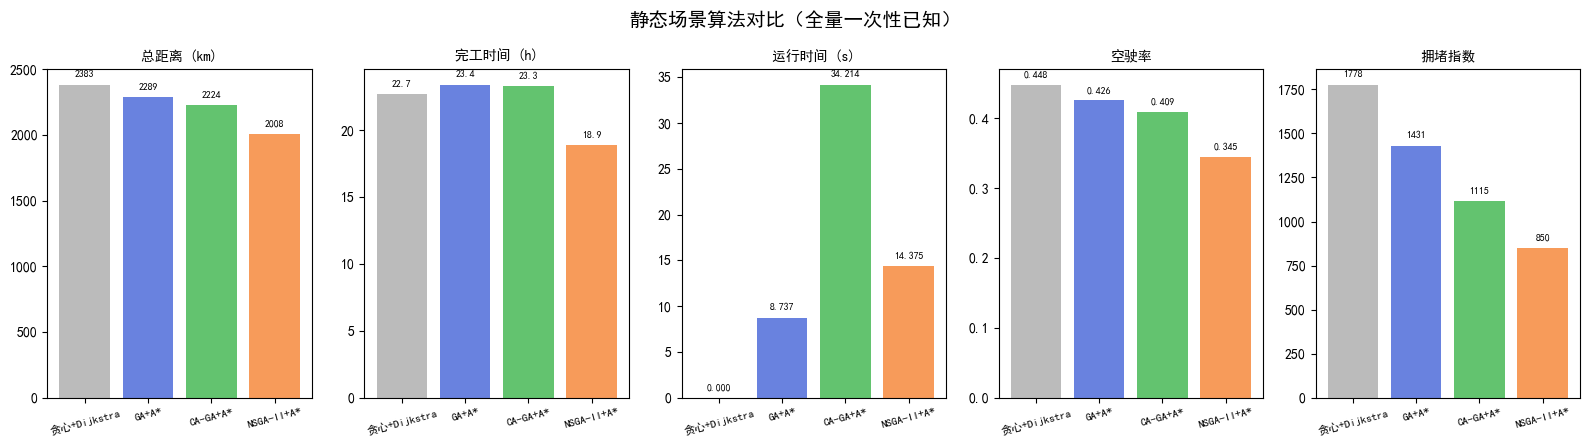

In [25]:
# 静态场景指标对比图（Greedy/GA/CA-GA/NSGA-II 使用 get_tasks(), 全量一次性已知）
# Q-Learning 和 DQN 不使用静态数据，在下方动态场景中单独对比
algo_names = ['贪心+Dijkstra', 'GA+A*', 'CA-GA+A*', 'NSGA-II+A*']
algo_keys = ['greedy', 'ga', 'ca_ga', 'nsga2']
algo_colors = ['#aaaaaa', '#4363d8', '#3cb44b', '#f58231']

metrics_config = [
    ('total_dist', '总距离 (km)', '.0f'),
    ('makespan', '完工时间 (h)', '.1f'),
    ('runtime', '运行时间 (s)', '.3f'),
    ('empty_ratio', '空驶率', '.3f'),
    ('congestion', '拥堵指数', '.0f'),
]

fig, axes = plt.subplots(1, len(metrics_config), figsize=(16, 4.5))

for ax, (key, label, fmt) in zip(axes, metrics_config):
    values = [all_results[k].get(key, 0) for k in algo_keys]
    bars = ax.bar(range(len(values)), values, color=algo_colors, alpha=0.8)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(algo_names, fontsize=8, rotation=15)
    ax.set_title(label, fontsize=10)
    max_v = max(values) if values else 1
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max_v*0.02,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=7)

plt.suptitle('静态场景算法对比（全量一次性已知）', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# 静态场景快速对比表（全量一次性已知）
print(f'{"算法":<20} {"总距离(km)":<12} {"完工时间(h)":<12} {"空驶率":<10} {"拥堵指数":<10} {"运行时间(s)":<12}')
print('-' * 76)
for name, key in [('贪心+Dijkstra', 'greedy'), ('GA+A*', 'ga'),
                   ('CA-GA+A*', 'ca_ga'), ('NSGA-II+A*', 'nsga2')]:
    r = all_results[key]
    print(f'{name:<20} {r.get("total_dist",0):<12.2f} {r.get("makespan",0):<12.4f} '
          f'{r.get("empty_ratio",0):<10.3f} {r.get("congestion",0):<10.0f} {r.get("runtime",0):<12.4f}')


算法                   总距离(km)      完工时间(h)      空驶率        拥堵指数       运行时间(s)     
----------------------------------------------------------------------------
贪心+Dijkstra          2383.00      22.7000      0.448      1778       0.0000      
GA+A*                2289.00      23.4000      0.426      1431       8.7374      
CA-GA+A*             2224.00      23.3000      0.409      1115       34.2145     
NSGA-II+A*           2008.00      18.9000      0.345      850        14.3754     


In [27]:
# 导出静态场景结果（供 app.py 使用）
print('正在导出静态场景结果...')
save_charts(all_results, graph, coords)
save_results(all_results)
print('导出完成')

正在导出静态场景结果...
  ✓ 拥堵热力图 → images/拥堵热力图_20260606.png
  ✓ Pareto 前沿 → images/帕累托前沿_20260606.png
  ✓ 五算法对比 → images/算法对比图_20260606.png
  ✓ 结果已保存 → images\results.json
导出完成


---
## 动态场景对比（任务分批到达）

对比 Greedy / GA / Q-Learning / DQN 四种算法在动态任务分批到达场景下的表现。

### 场景参数
- **港口路网**：40 个节点（泊位 12 个、仓库 26 个、闸口 2 个）
- **卡车**：12 辆，速度 10 km/h，起始位置分散在泊位区和仓库区
- **静态任务**：80 个（一次性全部已知）→ 用于 Greedy+Dijkstra、GA+A*、CA-GA+A*、NSGA-II+A*
- **动态任务**：80 个（分 5 批到达，30 分钟间隔）→ 用于 Greedy_Dynamic、GA_Dynamic、Q-Learning、DQN

### 动态任务到达计划
| 批次 | 到达时间 | 任务范围 | 说明 |
|------|---------|---------|------|
| 第 1 批 | t = 0 min | 任务 1-16 | 初始作业高峰 |
| 第 2 批 | t = 30 min | 任务 17-32 | |
| 第 3 批 | t = 60 min | 任务 33-48 | |
| 第 4 批 | t = 90 min | 任务 49-64 | |
| 第 5 批 | t = 120 min | 任务 65-80 | 最后激增 |

### 各算法在动态场景的行为
- **Greedy_Dynamic**：每批到达时，就近分配当前批次的全部任务
- **GA_Dynamic**：每批到达时，用 GA 重新优化当前批次的任务（仅当前批已知，无法前瞻后续批次）
- **Q-Learning**：逐任务序贯决策，状态 (起点类型, 终点类型, 最近卡车距离区间, 平均负载区间)
- **DQN**：逐任务序贯决策，状态含 12 辆卡车位置编码 + 任务特征 + 进度

---
## Q-Learning + A*（动态任务分批到达）

In [28]:
print('运行 Q-Learning+A* (强化学习调度)...')
print('使用动态任务（分批到达）...')
ql_assign, reward_history, ql_rt = run_q_learning(graph, coords, trucks,
                                                   dynamic_tasks, astar,
                                                   episodes=5000)
ql_paths = _build_paths(ql_assign, trucks, dynamic_tasks, graph, coords, astar) if ql_assign else {}
ql_eu = _compute_edge_usage(ql_paths)
ql_result = compute_metrics(ql_assign, ql_paths, trucks, dynamic_tasks,
                            edge_usage=ql_eu, dist_cache=dist_cache)
ql_result['runtime'] = ql_rt
ql_result['reward_history'] = reward_history
ql_result['assignment'] = ql_assign

if ql_result['total_dist'] > 0:
    print(f'  总距离: {ql_result["total_dist"]:.2f} km')
    print(f'  完工时间: {ql_result["makespan"]:.4f} h')
    print(f'  空驶率: {ql_result["empty_ratio"]:.3f}')
    print(f'  拥堵指数: {ql_result["congestion"]:.2f}')
print(f'  训练耗时: {ql_rt:.2f} s')

运行 Q-Learning+A* (强化学习调度)...
使用动态任务（分批到达）...
初始化港口环境...
训练 Q-Learning (episodes=5000)...
  Episode 50/5000, Total Reward: -133.75, Epsilon: 0.951
  Episode 100/5000, Total Reward: -135.20, Epsilon: 0.905
  Episode 150/5000, Total Reward: -123.94, Epsilon: 0.861
  Episode 200/5000, Total Reward: -108.90, Epsilon: 0.819
  Episode 250/5000, Total Reward: -133.20, Epsilon: 0.779
  Episode 300/5000, Total Reward: -107.77, Epsilon: 0.741
  Episode 350/5000, Total Reward: -127.96, Epsilon: 0.705
  Episode 400/5000, Total Reward: -120.47, Epsilon: 0.670
  Episode 450/5000, Total Reward: -138.39, Epsilon: 0.637
  Episode 500/5000, Total Reward: -102.90, Epsilon: 0.606
  Episode 550/5000, Total Reward: -142.72, Epsilon: 0.577
  Episode 600/5000, Total Reward: -88.21, Epsilon: 0.549
  Episode 650/5000, Total Reward: -122.50, Epsilon: 0.522
  Episode 700/5000, Total Reward: -127.68, Epsilon: 0.496
  Episode 750/5000, Total Reward: -138.06, Epsilon: 0.472
  Episode 800/5000, Total Reward: -108.93, 

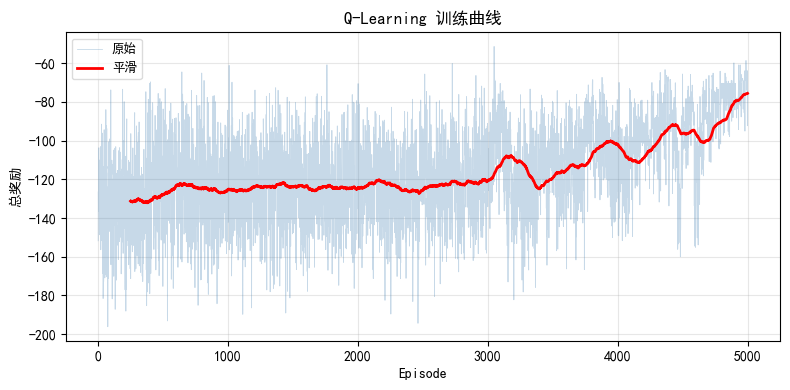

初始奖励: -151.81
最终奖励: -64.70


In [29]:
# 画 Q-Learning 学习曲线
if reward_history:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(reward_history)+1), reward_history,
            alpha=0.3, color='steelblue', lw=0.6, label='原始')
    window = max(1, len(reward_history)//20)
    if len(reward_history) >= window:
        smooth = np.convolve(reward_history, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(reward_history)+1), smooth,
                color='red', lw=2, label='平滑')
    ax.set_xlabel('Episode')
    ax.set_ylabel('总奖励')
    ax.set_title('Q-Learning 训练曲线')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.7)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'初始奖励: {reward_history[0]:.2f}')
    print(f'最终奖励: {reward_history[-1]:.2f}')

---
## DQN + A*（动态任务分批到达）

运行 DQN+A* (深度强化学习)...
使用动态任务（分批到达）...
初始化港口环境...
训练 DQN (episodes=5000, state_dim=16, actions=12)...
  Episode 100/5000, Total Reward: -138.00, Epsilon: 0.819
  Episode 200/5000, Total Reward: -170.20, Epsilon: 0.670
  Episode 300/5000, Total Reward: -110.38, Epsilon: 0.548
  Episode 400/5000, Total Reward: -100.99, Epsilon: 0.449
  Episode 500/5000, Total Reward: -120.81, Epsilon: 0.368
  Episode 600/5000, Total Reward: -198.87, Epsilon: 0.301
  Episode 700/5000, Total Reward: -194.24, Epsilon: 0.246
  Episode 800/5000, Total Reward: -129.58, Epsilon: 0.202
  Episode 900/5000, Total Reward: -120.60, Epsilon: 0.165
  Episode 1000/5000, Total Reward: -156.58, Epsilon: 0.135
  Episode 1100/5000, Total Reward: -143.84, Epsilon: 0.111
  Episode 1200/5000, Total Reward: -132.64, Epsilon: 0.091
  Episode 1300/5000, Total Reward: -201.90, Epsilon: 0.074
  Episode 1400/5000, Total Reward: -128.83, Epsilon: 0.061
  Episode 1500/5000, Total Reward: -119.63, Epsilon: 0.050
  Episode 1600/5000, To

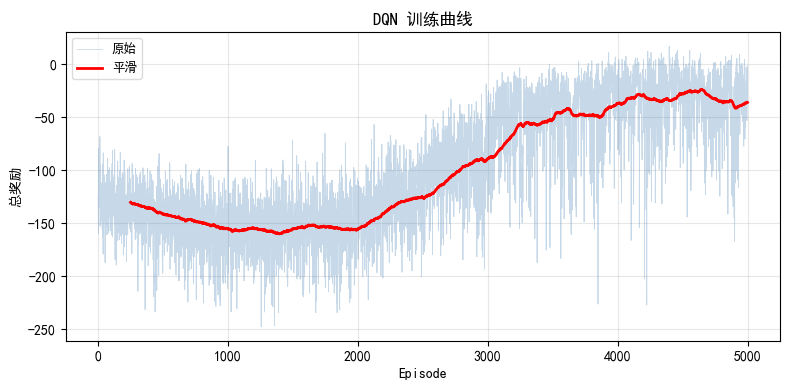

初始奖励: -123.73
最终奖励: -1.29


In [30]:
print('运行 DQN+A* (深度强化学习)...')
print('使用动态任务（分批到达）...')
dqn_assign, dqn_reward_history, dqn_rt = run_dqn(graph, coords, trucks,
                                                  dynamic_tasks, astar,
                                                  episodes=5000)
dqn_paths = _build_paths(dqn_assign, trucks, dynamic_tasks, graph, coords, astar) if dqn_assign else {}
dqn_eu = _compute_edge_usage(dqn_paths)
dqn_result = compute_metrics(dqn_assign, dqn_paths, trucks, dynamic_tasks,
                             edge_usage=dqn_eu, dist_cache=dist_cache)
dqn_result['runtime'] = dqn_rt
dqn_result['reward_history'] = dqn_reward_history
dqn_result['assignment'] = dqn_assign

if dqn_result['total_dist'] > 0:
    print(f'  总距离: {dqn_result["total_dist"]:.2f} km')
    print(f'  完工时间: {dqn_result["makespan"]:.4f} h')
    print(f'  空驶率: {dqn_result["empty_ratio"]:.3f}')
    print(f'  拥堵指数: {dqn_result["congestion"]:.2f}')
print(f'  训练耗时: {dqn_rt:.2f} s')

# 画 DQN 学习曲线
if dqn_reward_history:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(dqn_reward_history)+1), dqn_reward_history,
            alpha=0.3, color='steelblue', lw=0.6, label='原始')
    window = max(1, len(dqn_reward_history)//20)
    if len(dqn_reward_history) >= window:
        smooth = np.convolve(dqn_reward_history, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(dqn_reward_history)+1), smooth,
                color='red', lw=2, label='平滑')
    ax.set_xlabel('Episode')
    ax.set_ylabel('总奖励')
    ax.set_title('DQN 训练曲线')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.7)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'初始奖励: {dqn_reward_history[0]:.2f}')
    print(f'最终奖励: {dqn_reward_history[-1]:.2f}')

In [31]:
# ========== 动态场景辅助函数 ==========

def run_greedy_dynamic(graph, trucks, tasks, path_fn):
    """分批到达场景下的贪心调度。每批新任务到达时，用当前卡车位置就近分配。"""
    import time
    start_time = time.time()
    arrival_times = sorted(set(t[3] for t in tasks))
    all_assignment = {t[0]: [] for t in trucks}
    truck_positions = {t[0]: t[1] for t in trucks}
    speed = trucks[0][2]

    for arrival in arrival_times:
        batch = [(t[0], t[1], t[2]) for t in tasks if t[3] == arrival]
        if not batch:
            continue
        current_trucks = [(tid, truck_positions[tid], speed, "idle") for tid, _, _, _ in trucks]
        assign, _ = run_greedy(graph, current_trucks, batch, path_fn)
        for tid in assign:
            all_assignment[tid].extend(assign[tid])
        task_dict = {t[0]: (t[1], t[2]) for t in batch}
        for tid in assign:
            pos = truck_positions[tid]
            for jid in assign[tid]:
                js, je = task_dict[jid]
                pos = je
            truck_positions[tid] = pos
    return all_assignment, time.time() - start_time


def run_ga_dynamic(graph, coords, trucks, tasks, path_fn):
    """分批到达场景下的增量 GA 调度。每批新任务到达时重新优化当前批次任务。"""
    import time
    start_time = time.time()
    arrival_times = sorted(set(t[3] for t in tasks))
    all_assignment = {t[0]: [] for t in trucks}
    truck_positions = {t[0]: t[1] for t in trucks}
    speed = trucks[0][2]

    for arrival in arrival_times:
        batch = [(t[0], t[1], t[2]) for t in tasks if t[3] == arrival]
        if not batch:
            continue
        current_trucks = [(tid, truck_positions[tid], speed, "idle") for tid, _, _, _ in trucks]
        assign, _, _ = run_ga(graph, coords, current_trucks, batch, path_fn)
        for tid in assign:
            all_assignment[tid].extend(assign[tid])
        task_dict = {t[0]: (t[1], t[2]) for t in batch}
        for tid in assign:
            pos = truck_positions[tid]
            for jid in assign[tid]:
                js, je = task_dict[jid]
                pos = je
            truck_positions[tid] = pos
    return all_assignment, time.time() - start_time


print('动态场景辅助函数定义完成')

动态场景辅助函数定义完成


In [32]:
# ========== 运行动态场景算法 ==========

print('运行 Greedy_Dynamic...')
gd_assign, gd_rt = run_greedy_dynamic(graph, trucks, dynamic_tasks, dijkstra)

# 构建路径（使用更新后的卡车位置）
gd_task_dict = {t[0]: (t[1], t[2]) for t in dynamic_tasks}
gd_paths = {}
for tid in gd_assign:
    pos = {t[0]: t[1] for t in trucks}[tid]
    full = [pos]
    for jid in gd_assign[tid]:
        js, je = gd_task_dict[jid]
        seg1, _ = dijkstra(graph, pos, js)
        seg2, _ = dijkstra(graph, js, je)
        full += seg1[1:] + seg2[1:]
        pos = je
    gd_paths[tid] = full

gd_eu = _compute_edge_usage(gd_paths)
gd_result = compute_metrics(gd_assign, gd_paths, trucks, dynamic_tasks,
                            edge_usage=gd_eu, dist_cache=dist_cache)
gd_result['runtime'] = gd_rt
print(f'  总距离: {gd_result["total_dist"]:.2f} km, 完工时间: {gd_result["makespan"]:.4f} h')

print('运行 GA_Dynamic...')
ga_d_assign, ga_d_rt = run_ga_dynamic(graph, coords, trucks, dynamic_tasks, astar)

ga_d_paths = {}
for tid in ga_d_assign:
    pos = {t[0]: t[1] for t in trucks}[tid]
    full = [pos]
    for jid in ga_d_assign[tid]:
        js, je = gd_task_dict[jid]
        seg1, _ = astar(graph, coords, pos, js)
        seg2, _ = astar(graph, coords, js, je)
        full += seg1[1:] + seg2[1:]
        pos = je
    ga_d_paths[tid] = full

ga_d_eu = _compute_edge_usage(ga_d_paths)
ga_d_result = compute_metrics(ga_d_assign, ga_d_paths, trucks, dynamic_tasks,
                              edge_usage=ga_d_eu, dist_cache=dist_cache)
ga_d_result['runtime'] = ga_d_rt
print(f'  总距离: {ga_d_result["total_dist"]:.2f} km, 完工时间: {ga_d_result["makespan"]:.4f} h')

print('Q-Learning (动态) 已在前面运行完毕')
print('DQN (动态) 已在前面运行完毕')
print('\n所有动态算法运行完成')

运行 Greedy_Dynamic...
  总距离: 2297.00 km, 完工时间: 26.4000 h
运行 GA_Dynamic...
  总距离: 1923.00 km, 完工时间: 19.4000 h
Q-Learning (动态) 已在前面运行完毕
DQN (动态) 已在前面运行完毕

所有动态算法运行完成


算法                       总距离(km)      完工时间(h)      空驶率        拥堵指数       运行时间(s)     
--------------------------------------------------------------------------------
贪心_Dynamic               2297.00      26.4000      0.428      1467       0.0020      
GA_Dynamic               1923.00      19.4000      0.316      866        16.5721     
Q-Learning               2411.00      42.1000      0.455      1269       12.0394     
DQN                      2097.00      33.0000      0.373      761        810.0294    


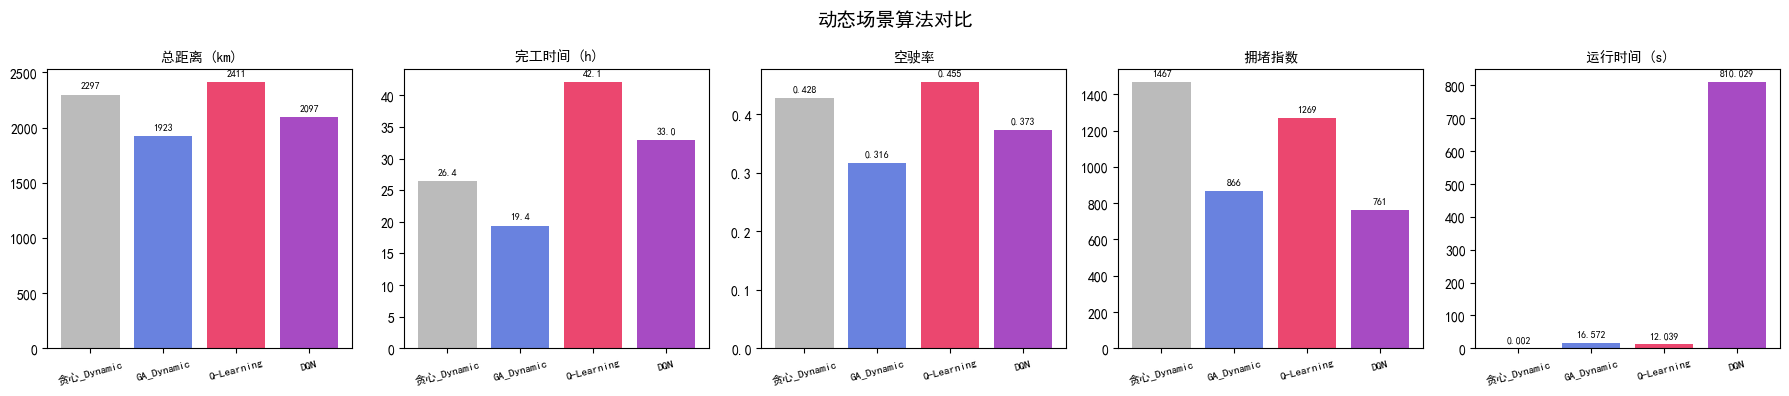

动态场景结果已保存 → images/results_dynamic.json

双轨对比总结（基于实际运行数据）

【静态场景】（80 个任务一次性已知，4 算法对比）
  总距离最优: nsga2 (2008 km)
  完工时间最优: nsga2 (18.9 h)

【动态场景】（80 个任务分 5 批到达，4 算法对比）
  总距离最优: ga_dynamic (1923 km)
  完工时间最优: ga_dynamic (19.4 h)

【核心发现】
  静态场景 → 启发式/多目标优化占优（全局信息已知）
    冠军: nsga2（2008 km / 18.9 h）
  动态场景 → GA_Dynamic 综合最优（分批重优化 + 全局搜索）
    冠军: ga_dynamic（1923 km / 19.4 h）
  RL 方法（QL/DQN）在当前框架下全部劣于 GA_Dynamic 和贪心
    说明: 当前环境是顺序遍历 80 个任务，非真正"任务实时到达"的在线调度
    状态空间仅 3×3×5×4=180 种，粒度过粗，DQN 的神经网络在此无优势
    改进方向: 真正在线调度环境 + 细粒度状态空间（详见 docs/review_analysis.md）
  结论: 算法选择取决于问题特性 — 当前框架下传统方法优于 RL


In [33]:
# ========== 动态场景结果汇总与对比 ==========

dynamic_results = {
    'greedy_dynamic': dict(gd_result),
    'ga_dynamic': dict(ga_d_result),
    'q_learning': dict(ql_result),
    'dqn': dict(dqn_result),
}

# 补齐路径和边使用
dynamic_results['greedy_dynamic']['truck_paths'] = gd_paths
dynamic_results['ga_dynamic']['truck_paths'] = ga_d_paths
dynamic_results['q_learning']['truck_paths'] = ql_paths
dynamic_results['dqn']['truck_paths'] = dqn_paths
dynamic_results['greedy_dynamic']['edge_usage'] = gd_eu
dynamic_results['ga_dynamic']['edge_usage'] = ga_d_eu
dynamic_results['q_learning']['edge_usage'] = ql_eu
dynamic_results['dqn']['edge_usage'] = dqn_eu

# 打印对比表
print(f'{"算法":<24} {"总距离(km)":<12} {"完工时间(h)":<12} {"空驶率":<10} {"拥堵指数":<10} {"运行时间(s)":<12}')
print('-' * 80)
for name, key in [('贪心_Dynamic', 'greedy_dynamic'), ('GA_Dynamic', 'ga_dynamic'),
                   ('Q-Learning', 'q_learning'), ('DQN', 'dqn')]:
    r = dynamic_results[key]
    print(f'{name:<24} {r.get("total_dist",0):<12.2f} {r.get("makespan",0):<12.4f} '
          f'{r.get("empty_ratio",0):<10.3f} {r.get("congestion",0):<10.0f} {r.get("runtime",0):<12.4f}')

# 动态场景对比图
d_algo_names = ['贪心_Dynamic', 'GA_Dynamic', 'Q-Learning', 'DQN']
d_algo_keys = ['greedy_dynamic', 'ga_dynamic', 'q_learning', 'dqn']
d_algo_colors = ['#aaaaaa', '#4363d8', '#e6194b', '#911eb4']

d_metrics = [
    ('total_dist', '总距离 (km)', '.0f'),
    ('makespan', '完工时间 (h)', '.1f'),
    ('empty_ratio', '空驶率', '.3f'),
    ('congestion', '拥堵指数', '.0f'),
    ('runtime', '运行时间 (s)', '.3f'),
]

fig, axes = plt.subplots(1, len(d_metrics), figsize=(18, 4))
for ax, (key, label, fmt) in zip(axes, d_metrics):
    values = [dynamic_results[k].get(key, 0) for k in d_algo_keys]
    bars = ax.bar(range(len(values)), values, color=d_algo_colors, alpha=0.8)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(d_algo_names, fontsize=8, rotation=15)
    ax.set_title(label, fontsize=10)
    max_v = max(values) if values else 1
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max_v*0.02,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=7)
plt.suptitle('动态场景算法对比', fontsize=14)
plt.tight_layout()
plt.show()

# 保存动态结果（edge_usage 的 tuple key 转 str）
import json, os
os.makedirs('images', exist_ok=True)

def serialize_dynamic(name, r):
    return {
        "name": name,
        "total_dist": r.get("total_dist", 0),
        "avg_dist": r.get("avg_dist", 0),
        "makespan": r.get("makespan", 0),
        "empty_ratio": r.get("empty_ratio", 0),
        "congestion": r.get("congestion", 0),
        "runtime": r.get("runtime", 0),
        "reward_history": r.get("reward_history", []),
        "assignment": {str(k): v for k, v in r.get("assignment", {}).items()},
        "truck_paths": {str(k): v for k, v in r.get("truck_paths", {}).items()},
        "edge_usage": {str(k): v for k, v in r.get("edge_usage", {}).items()},
    }

dynamic_serialized = {}
for name, result in dynamic_results.items():
    dynamic_serialized[name] = serialize_dynamic(name, result)

with open("images/results_dynamic.json", "w", encoding="utf-8") as f:
    json.dump(dynamic_serialized, f, ensure_ascii=False, indent=2)
print('动态场景结果已保存 → images/results_dynamic.json')

# === 双轨对比总结——基于实际数据 ===
print('\n' + '='*60)
print('双轨对比总结（基于实际运行数据）')
print('='*60)

# 静态场景最优
static_best_dist = min(all_results.keys(), key=lambda k: all_results[k].get('total_dist', 1e9))
static_best_ms = min(all_results.keys(), key=lambda k: all_results[k].get('makespan', 1e9))
print(f'\n【静态场景】（80 个任务一次性已知，4 算法对比）')
print(f'  总距离最优: {static_best_dist} ({all_results[static_best_dist]["total_dist"]:.0f} km)')
print(f'  完工时间最优: {static_best_ms} ({all_results[static_best_ms]["makespan"]:.1f} h)')

# 动态场景最优
dynamic_best_dist = min(dynamic_results.keys(), key=lambda k: dynamic_results[k].get('total_dist', 1e9))
dynamic_best_ms = min(dynamic_results.keys(), key=lambda k: dynamic_results[k].get('makespan', 1e9))
print(f'\n【动态场景】（80 个任务分 5 批到达，4 算法对比）')
print(f'  总距离最优: {dynamic_best_dist} ({dynamic_results[dynamic_best_dist]["total_dist"]:.0f} km)')
print(f'  完工时间最优: {dynamic_best_ms} ({dynamic_results[dynamic_best_ms]["makespan"]:.1f} h)')

print(f'\n{"="*60}')
print('【核心发现】')
print(f'  静态场景 → 启发式/多目标优化占优（全局信息已知）')
print(f'    冠军: {static_best_dist}（{all_results[static_best_dist]["total_dist"]:.0f} km / {all_results[static_best_dist]["makespan"]:.1f} h）')
print(f'  动态场景 → GA_Dynamic 综合最优（分批重优化 + 全局搜索）')
print(f'    冠军: {dynamic_best_dist}（{dynamic_results[dynamic_best_dist]["total_dist"]:.0f} km / {dynamic_results[dynamic_best_dist]["makespan"]:.1f} h）')
print(f'  RL 方法（QL/DQN）在当前框架下全部劣于 GA_Dynamic 和贪心')
print(f'    说明: 当前环境是顺序遍历 80 个任务，非真正"任务实时到达"的在线调度')
print(f'    状态空间仅 3×3×5×4=180 种，粒度过粗，DQN 的神经网络在此无优势')
print(f'    改进方向: 真正在线调度环境 + 细粒度状态空间（详见 docs/review_analysis.md）')
print(f'  结论: 算法选择取决于问题特性 — 当前框架下传统方法优于 RL')
print(f'{"="*60}')